In [1]:
import os
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')

def image_transform(test=False):
    # normalize = transforms.Normalize(
    #     mean=[0.4914, 0.4822, 0.4465],
    #     std=[0.2023, 0.1994, 0.2010],
    # )
    mid_transforms = [
    ] if test else [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomVerticalFlip(),
        transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
        transforms.ColorJitter(),
        # transforms.GaussianBlur(5),
    ]
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
    ] + mid_transforms + [
        transforms.Resize((224,224)),
        # normalize,
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform(test=True)
    image = read_image(path)
    image = transform(image)
    return image

In [4]:
def load_paths(root_dir) -> list:
    filenames = next(os.walk(root_dir), (None, None, []))[2]
    return [os.path.join(root_dir, filename) for filename in filenames]

In [5]:
images_path = '../data/logos'

In [6]:
max_width = 0
max_height = 0
min_width = 1000
min_height = 1000
for path in load_paths(images_path)[:5]:
    image = read_image(path)
    assert image.size()[0] == 3
    width, height = image.size()[1], image.size()[2]
    max_width = max(max_width, width)
    max_height = max(max_height, height)
    min_width = min(min_width, width)
    min_height = min(min_height, height)
print(f'Min size: {min_width}x{min_height}')
print(f'Max size: {max_width}x{max_height}')

Min size: 334x553
Max size: 944x944


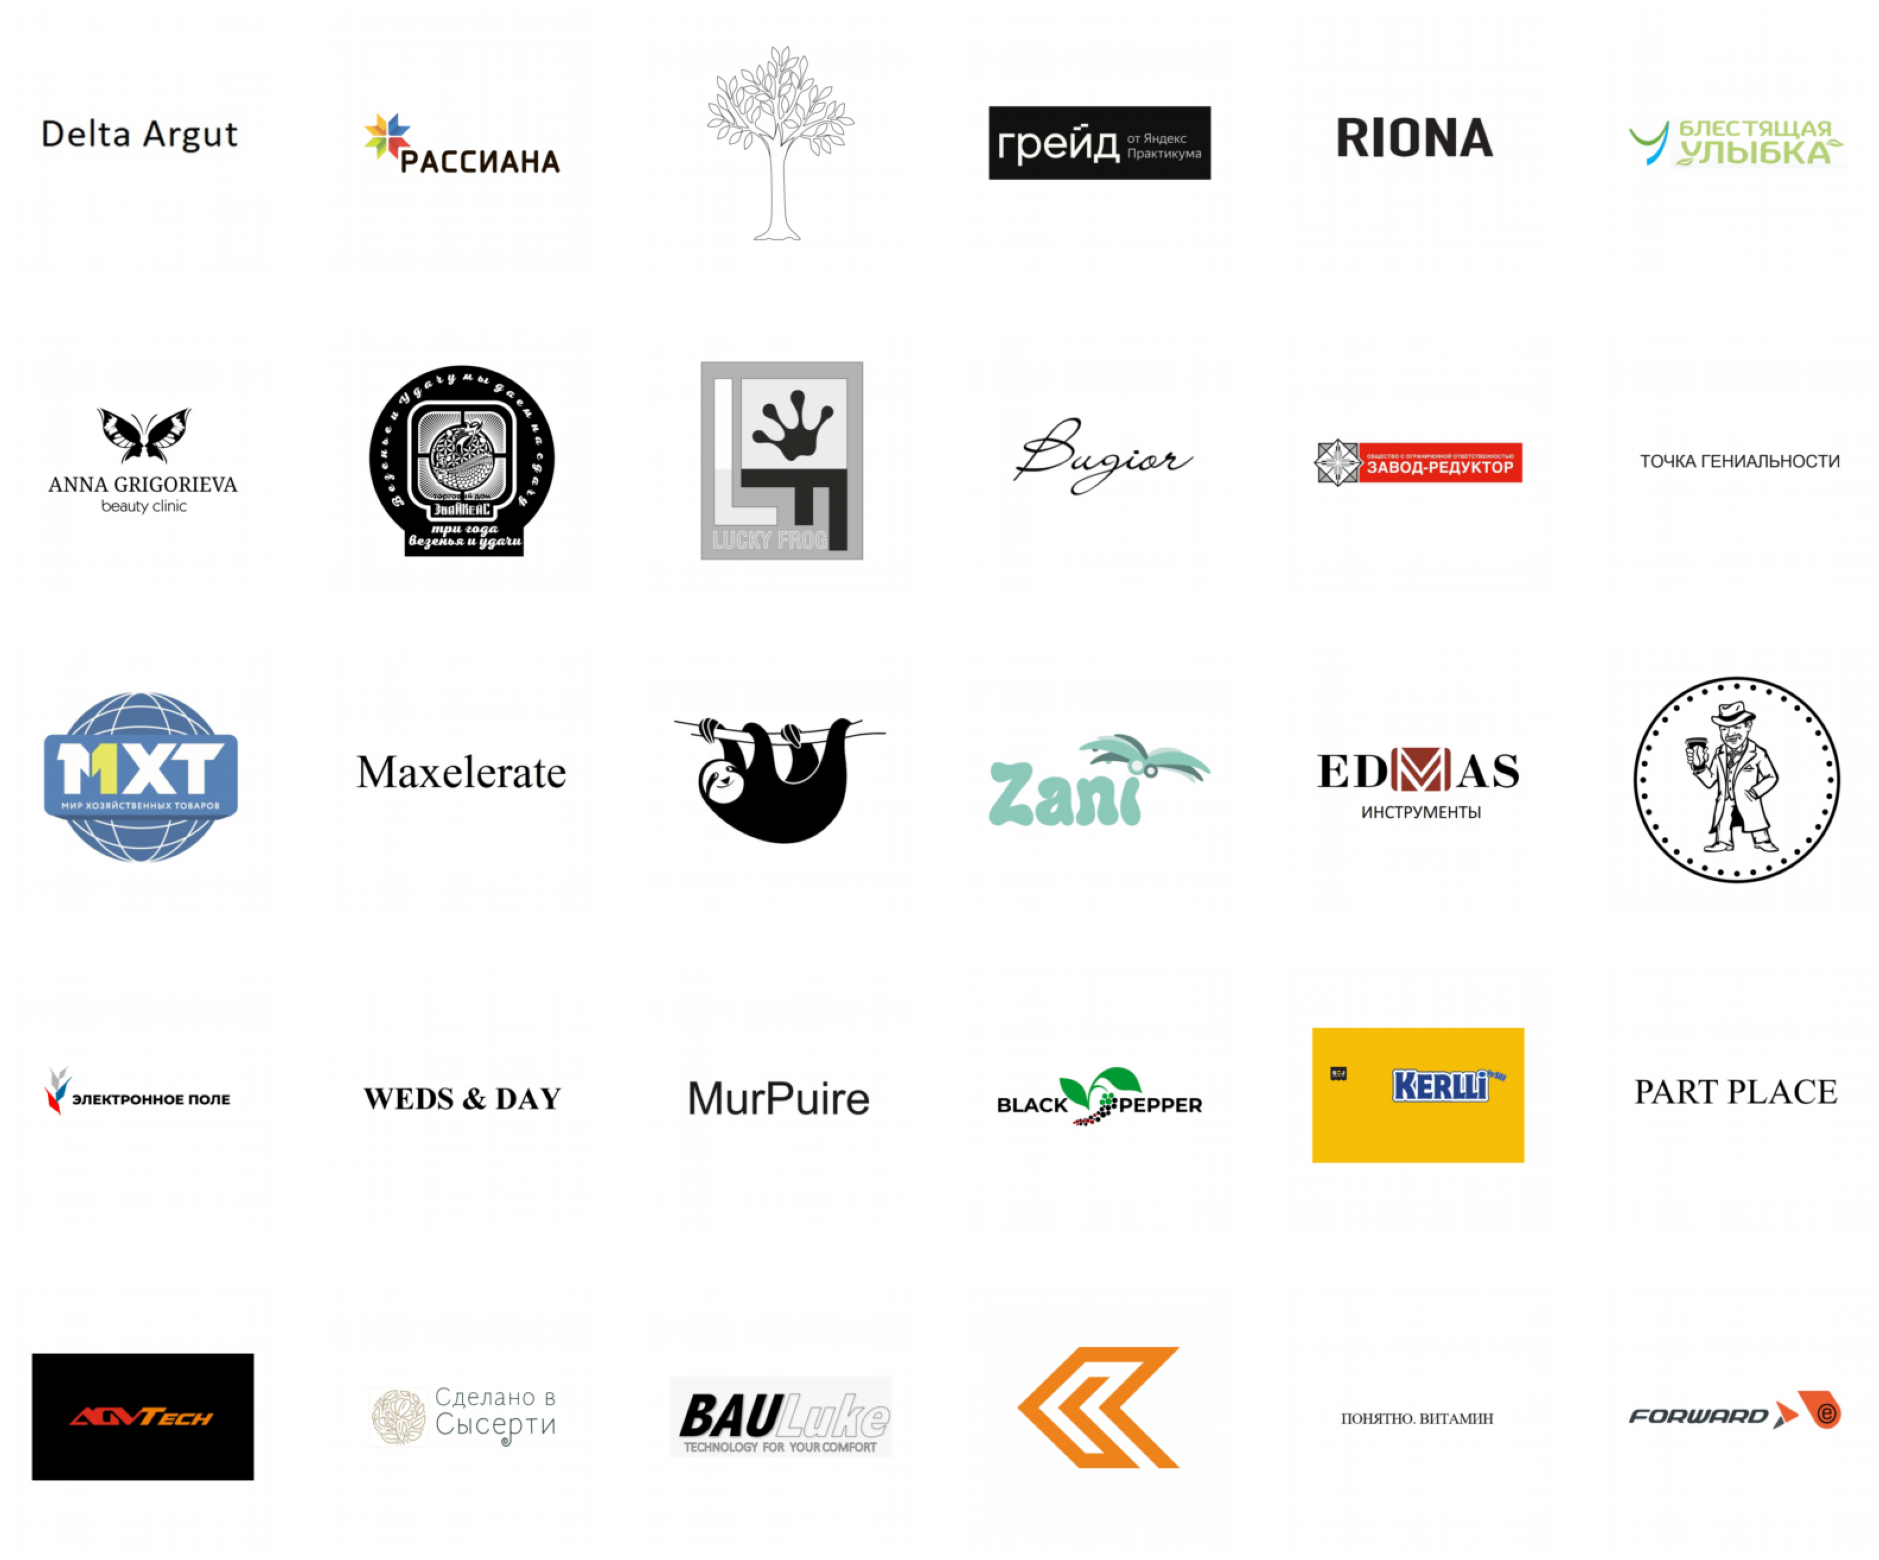

In [7]:
w, h = 6, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

for i, (img_path, ax) in enumerate(zip(image_paths, axs.flatten())):
    img = load_image(img_path)
    #prediction = model(img.unsqueeze(0).to(device)).item()

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_axis_off()
    #ax.set_title(f'Labelled: {label:.0f}, Predicted: {prediction:.0f}')

plt.show()

In [8]:
class LogosDataset(Dataset):
    def __init__(self, root_dir, frames_limit=None, transform=None):
        self.root = root_dir
        self.transform = transform

        self.images = []

        images = load_paths(root_dir)
        image_paths = []

        if frames_limit is None:
            image_paths = images
        else:
            np.random.shuffle(images)
            image_paths.extend(images[:frames_limit])

        self.images.extend(image_paths)

        print(f'loaded {len(self.images)} paths')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image, img_path

In [9]:
def data_loader(data_dir, batch_size, frames_limit=None, shuffle=True, test=False):
    transform = image_transform(test)
    dataset = LogosDataset(data_dir, frames_limit, transform)

    indices = list(range(len(dataset)))
    if shuffle:
        np.random.shuffle(indices)

    sampler = SubsetRandomSampler(indices)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    return loader

In [10]:
loader = data_loader('../data/logos', 32)

loaded 1000 paths


In [11]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [12]:
def generate_embeddings(model):
    model = model.to(device)
    embeddings = torch.tensor([]).to(device)
    all_paths = []
    for images, paths in tqdm(loader):
        encoding = model(images.to(device)).detach()
        embeddings = torch.cat((embeddings, encoding))
        all_paths += paths
    return embeddings, all_paths

In [13]:
image_embeddings, image_embedding_paths = generate_embeddings(model)
image_embeddings

100%|██████████| 32/32 [00:32<00:00,  1.01s/it]


tensor([[-3.0711, -2.2036, -3.0508,  ..., -3.0574, -0.7901,  3.4694],
        [-3.1503, -0.7534, -4.0712,  ..., -3.7188, -0.8237,  1.9197],
        [-5.6100, -2.6960, -3.5131,  ..., -3.7435,  2.0382,  3.5206],
        ...,
        [-4.2435, -1.4826, -3.7185,  ..., -3.2182, -1.1875,  3.7180],
        [-5.5099, -4.9906, -3.5498,  ..., -2.8611, -3.0557,  2.4861],
        [-3.0122, -2.3245, -3.5013,  ..., -3.7176,  1.2966,  3.0801]],
       device='cuda:0')

In [14]:
def compute_similarity(image_path, embeddings):
    image = load_image(image_path)
    encoded = model.to(device)(image.unsqueeze(0).to(device)).detach()

    similarity_fn = nn.CosineSimilarity()
    def similarity(other_enc):
        return similarity_fn(encoded, other_enc)
    similarity_vec = torch.vmap(similarity)
    return similarity_vec(embeddings)

In [15]:
compute_similarity(image_embedding_paths[0], image_embeddings)

tensor([[0.5496],
        [0.6206],
        [0.5368],
        [0.5146],
        [0.5089],
        [0.7581],
        [0.7373],
        [0.5763],
        [0.5187],
        [0.5954],
        [0.8056],
        [0.6868],
        [0.7065],
        [0.5719],
        [0.6886],
        [0.6321],
        [0.6133],
        [0.5165],
        [0.8418],
        [0.6992],
        [0.8763],
        [0.6960],
        [0.5944],
        [0.5453],
        [0.4829],
        [0.4679],
        [0.7874],
        [0.5131],
        [0.5510],
        [0.5506],
        [0.5496],
        [0.6815],
        [0.6585],
        [0.6402],
        [0.8153],
        [0.4587],
        [0.5274],
        [0.8095],
        [0.5244],
        [0.6557],
        [0.4463],
        [0.5610],
        [0.5979],
        [0.6468],
        [0.4825],
        [0.5848],
        [0.5312],
        [0.3794],
        [0.7905],
        [0.6118],
        [0.6425],
        [0.7850],
        [0.5017],
        [0.5318],
        [0.5906],
        [0

10it [00:00, 24.73it/s]


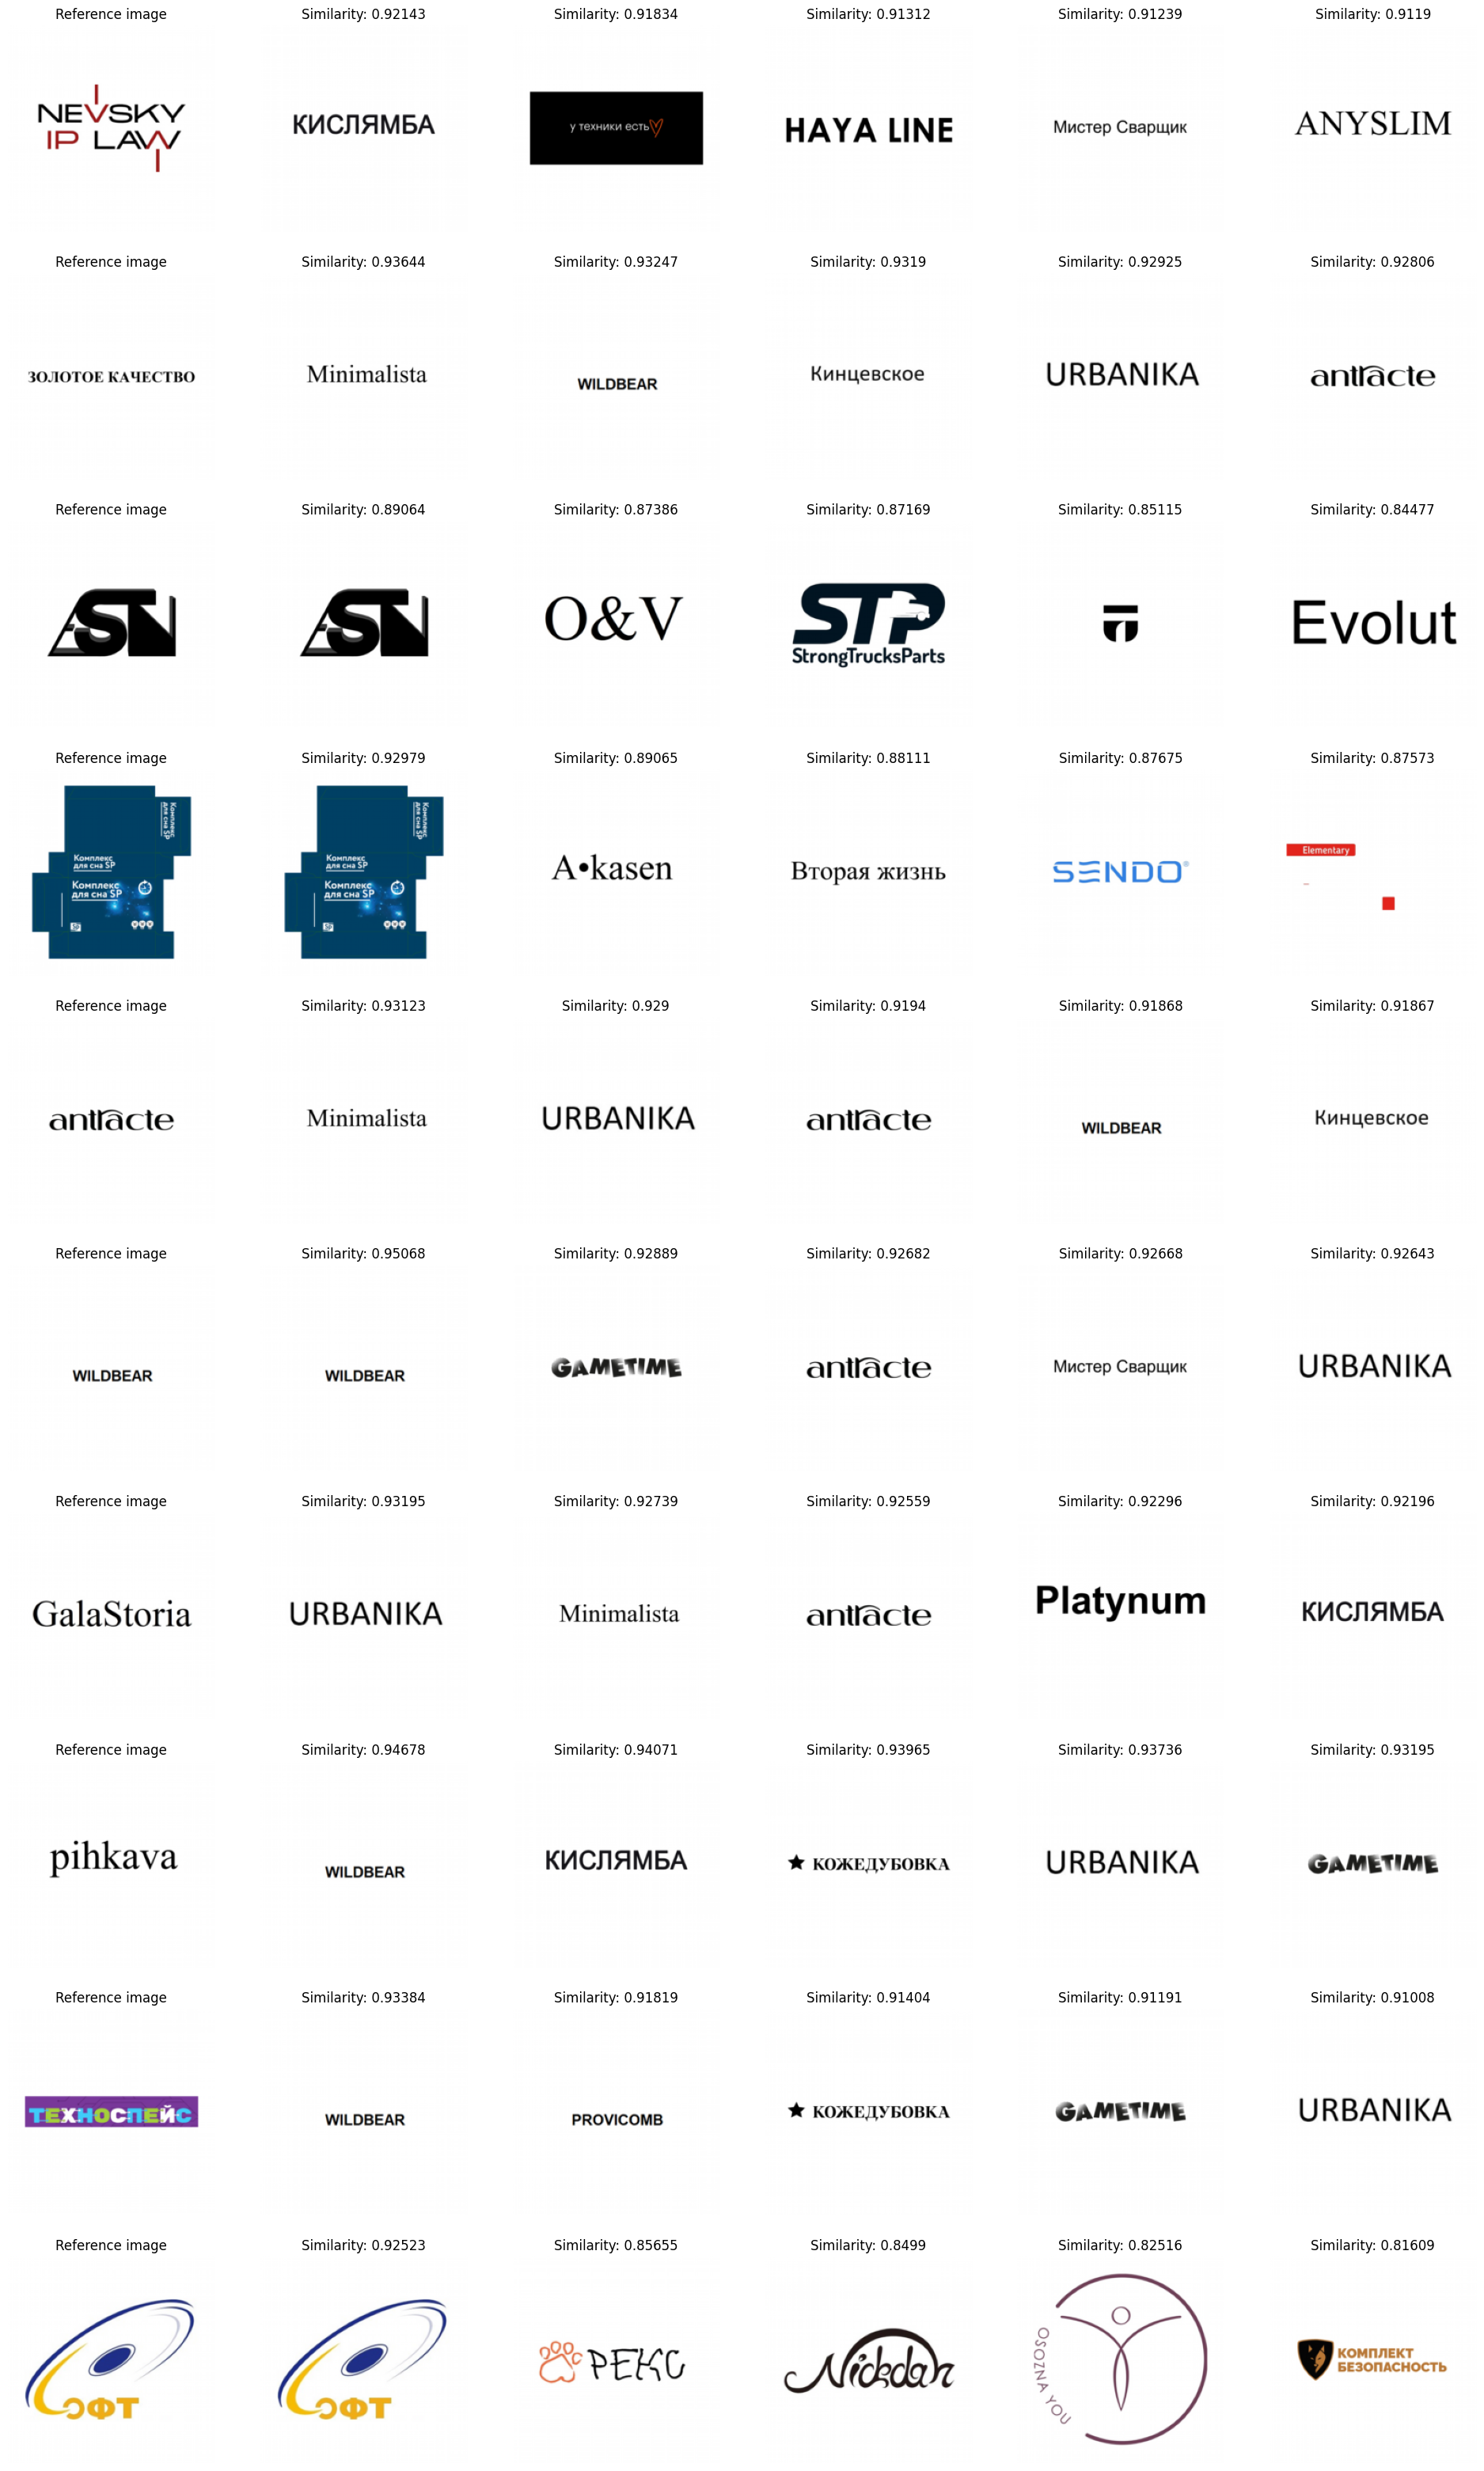

In [16]:
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

similarity_fn = nn.CosineSimilarity()
model.eval()
for i, ax_row in tqdm(enumerate(axs)):
    img_path = image_paths[i]
    
    similarities = compute_similarity(img_path, image_embeddings).cpu().numpy().flatten()
    top_images = np.argsort(similarities)[::-1]

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title('Reference image')
        else:
            idx = top_images[i - 1]
            img = load_image(image_embedding_paths[idx])
            similarity = similarities[idx]
            ax.set_title(f'Similarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

In [17]:
detection_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
detection_model.classifier.append(nn.Linear(1000, 2)) # 2 classes: text, logo
detection_model.classifier.append(nn.Sigmoid())
load_model(detection_model, '../models/text_detect.safetensors')
detection_model = detection_model.to(device)
detection_model.eval()
detection_model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [18]:
classification, classification_path = generate_embeddings(detection_model)
classification

100%|██████████| 32/32 [00:33<00:00,  1.05s/it]


tensor([[0.1048, 0.9239],
        [0.0017, 0.9988],
        [0.0163, 0.9717],
        ...,
        [0.5398, 0.4593],
        [0.3398, 0.6627],
        [0.9267, 0.0674]], device='cuda:0')

In [19]:
logo_indices = []
for i in range(len(classification_path)):
    cl = classification[i]
    if cl[1] > 0.5: # 50% confidence of logo
        logo_indices.append(i)
logo_indices

[0,
 1,
 2,
 9,
 10,
 12,
 13,
 14,
 18,
 19,
 21,
 22,
 23,
 24,
 26,
 27,
 29,
 36,
 37,
 38,
 39,
 40,
 44,
 45,
 47,
 49,
 50,
 52,
 53,
 54,
 60,
 64,
 65,
 67,
 69,
 75,
 76,
 77,
 80,
 81,
 83,
 85,
 87,
 91,
 92,
 93,
 94,
 97,
 100,
 102,
 104,
 105,
 109,
 111,
 113,
 114,
 115,
 117,
 121,
 122,
 126,
 127,
 128,
 131,
 132,
 135,
 139,
 141,
 143,
 145,
 148,
 149,
 154,
 157,
 158,
 162,
 165,
 167,
 168,
 170,
 171,
 175,
 178,
 179,
 184,
 185,
 186,
 187,
 188,
 190,
 192,
 198,
 199,
 200,
 202,
 204,
 205,
 207,
 208,
 209,
 211,
 212,
 215,
 216,
 223,
 225,
 227,
 229,
 231,
 232,
 236,
 237,
 242,
 243,
 244,
 245,
 246,
 249,
 254,
 256,
 257,
 258,
 261,
 262,
 264,
 265,
 266,
 267,
 268,
 272,
 274,
 275,
 280,
 283,
 284,
 285,
 286,
 288,
 289,
 290,
 291,
 293,
 294,
 295,
 296,
 297,
 299,
 300,
 301,
 302,
 305,
 307,
 309,
 310,
 311,
 313,
 314,
 316,
 317,
 320,
 321,
 322,
 326,
 327,
 329,
 330,
 334,
 335,
 337,
 338,
 340,
 341,
 343,
 348,
 350,
 3

10it [00:00, 20.11it/s]


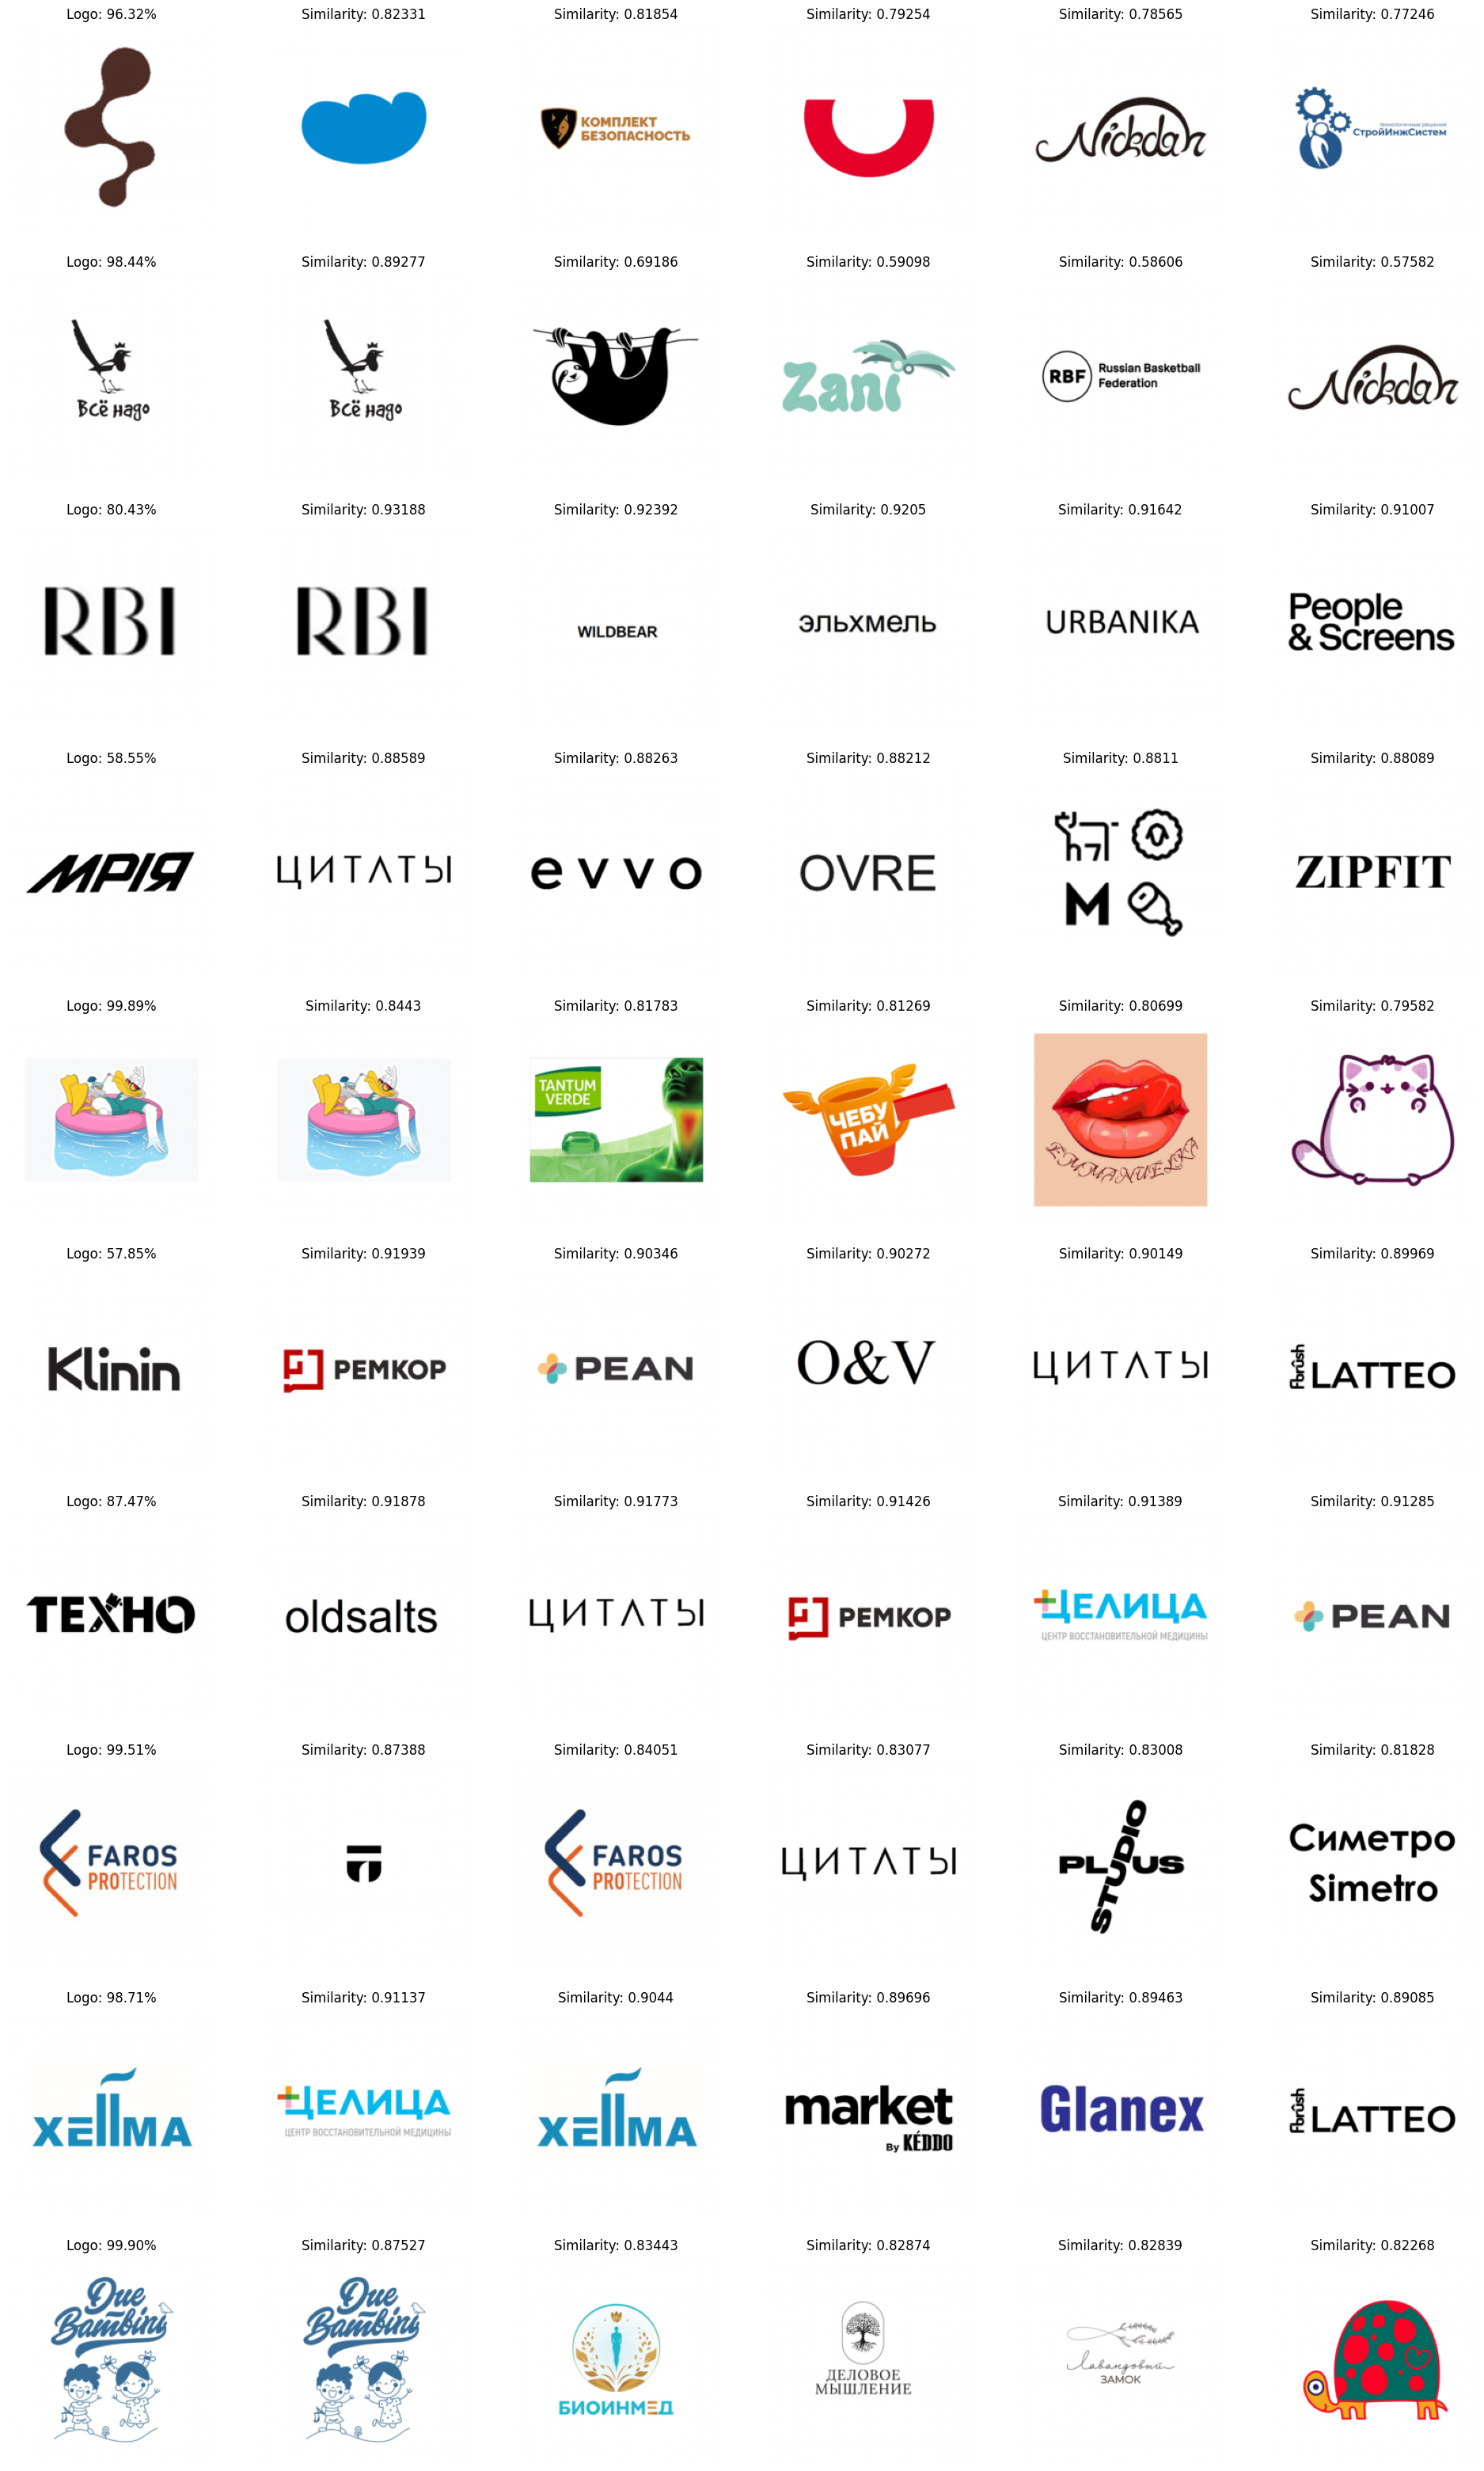

In [21]:
# Use the text-detection model to only check logos
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

np.random.shuffle(logo_indices)

for i, ax_row in tqdm(enumerate(axs)):
    img_index = logo_indices[i]
    img_path = classification_path[img_index]
    cl = classification[img_index]
    logo_confidence = cl[1].item() * 100

    similarities = compute_similarity(img_path, image_embeddings).cpu().numpy().flatten()
    top_images = np.argsort(similarities)[::-1]

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'Logo: {logo_confidence:.2f}%', )
        else:
            idx = top_images[i - 1]
            img = load_image(image_embedding_paths[idx])
            similarity = similarities[idx]
            ax.set_title(f'Similarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()